In [2]:
import sys
import pickle
from codebot.tokenizer import train_bpe

sys.path.append('.')

vocab_size = 1000
text = open('codebot/tiny_codes.txt').read()
merge_rules = train_bpe(text, vocab_size)

with open('codebot/merge_rules.pkl', 'wb') as f:
    pickle.dump(merge_rules, f)

Training BPE: 100%|██████████| 743/743 [11:56<00:00,  1.04it/s]


In [3]:
import sys
from codebot.tokenizer import BPETokenizer

sys.path.append('.')

tokenizer = BPETokenizer.load_from('codebot/merge_rules.pkl')

print('처음 학습된 10개')
for token_id in range(256, 266):
    byte_seq = tokenizer.id_to_bytes[token_id]
    text = byte_seq.decode('utf-8')
    print(token_id, text)

print('마지막 학습된 10개')
for token_id in range(990, 1000):
    byte_seq = tokenizer.id_to_bytes[token_id]
    text = byte_seq.decode('utf-8')
    print(token_id, text)

sample_text = open('codebot/tiny_codes.txt').read()[:10000]

byte_count = len(sample_text.encode('utf-8'))
ids = tokenizer.encode(sample_text)
ids_count = len(ids)
compression_ratio = byte_count / ids_count

print('바이트 수: ', byte_count)
print('토큰 수: ', ids_count)
print('압축률: ', compression_ratio)

처음 학습된 10개
256   
257     
258 in
259    
260 re
261 or
262  =
263 st
264 te
265 
   
마지막 학습된 10개
990 Error
991  ''
992 atter
993 St
994 thod
995  on
996 cle
997  R
998 ery
999 <|endoftext|>
바이트 수:  10000
토큰 수:  4709
압축률:  2.1235931195582927


In [4]:
import sys
import numpy as np
from codebot.tokenizer import BPETokenizer

sys.path.append('.')

tokenizer = BPETokenizer.load_from('codebot/merge_rules.pkl')

text = open('codebot/tiny_codes.txt').read()
ids = tokenizer.encode(text, show_progress= True)

ids_array = np.array(ids, dtype= np.uint16)
ids_array.tofile('codebot/tiny_codes.bin')

print(len(ids_array))
print(ids_array[:20])

Encoding: 100%|██████████| 43671/43671 [04:12<00:00, 173.05it/s]


2677398
[116 528 821 262 544  10 119 717 660  58 265 268 528 107 262 595 338  69
 669 273]


In [5]:
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
import matplotlib.pyplot as plt
from itertools import cycle
from tqdm import tqdm

from codebot.model import GPT
from codebot.utils import get_device

sys.path.append('.')

device = get_device()
data_path = 'codebot/tiny_codes.bin'
tokenizer_path = 'codebot/merge_rules.pkl'
model_save_path = 'codebot/model_pretrain.pt'

context_len = 256
vocab_size = 1000
batch_size = 32
learning_rate = 3e-4

max_iters = 20000
# max_iters = 20
embed_dim = 384
n_head = 6
n_layer = 6
ff_dim = 4 * embed_dim
dropout_rate = 0.1

In [8]:
class TokenDataset(Dataset):
    def __init__(self, tokens, context_len):
        self.tokens = torch.tensor(tokens, dtype = torch.long)
        self.context_len = context_len

    def __len__(self):
        return len(self.tokens) - self.context_len

    def __getitem__(self, idx):
        x = self.tokens[idx:idx + self.context_len]
        y = self.tokens[idx + 1: idx + self.context_len + 1]
        return x, y

In [9]:
import numpy as np

ids = np.fromfile(data_path, dtype = np.uint16)
dataset = TokenDataset(ids, context_len)
dataloader = DataLoader(dataset, batch_size= batch_size, shuffle= True)

model = GPT(
    vocab_size = vocab_size,
    max_context_len= context_len,
    embed_dim= embed_dim,
    n_head= n_head,
    n_layer= n_layer,
    ff_dim= ff_dim,
    dropout_rate= dropout_rate
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr = learning_rate)

total_params = sum(p.numel() for p in model.parameters())
print('파라미터 수: ', total_params)

losses = []
data_iter = cycle(dataloader)
pbar = tqdm(range(max_iters))

파라미터 수:  11121640


  0%|          | 0/20000 [00:00<?, ?it/s]

100%|██████████| 20000/20000 [40:15<00:00,  8.28it/s, loss=0.6441]
C:\Users\KDS23\AppData\Local\Temp\ipykernel_14196\2849795603.py:22: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.savefig('loss.pretrain.png')
C:\Users\KDS23\AppData\Local\Temp\ipykernel_14196\2849795603.py:22: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  plt.savefig('loss.pretrain.png')
C:\Users\KDS23\AppData\Local\Temp\ipykernel_14196\2849795603.py:22: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  plt.savefig('loss.pretrain.png')
C:\Users\KDS23\AppData\Local\Temp\ipykernel_14196\2849795603.py:22: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.savefig('loss.pretrain.png')
c:\Users\KDS23\Documents\17-KDT\17-codebot\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu San

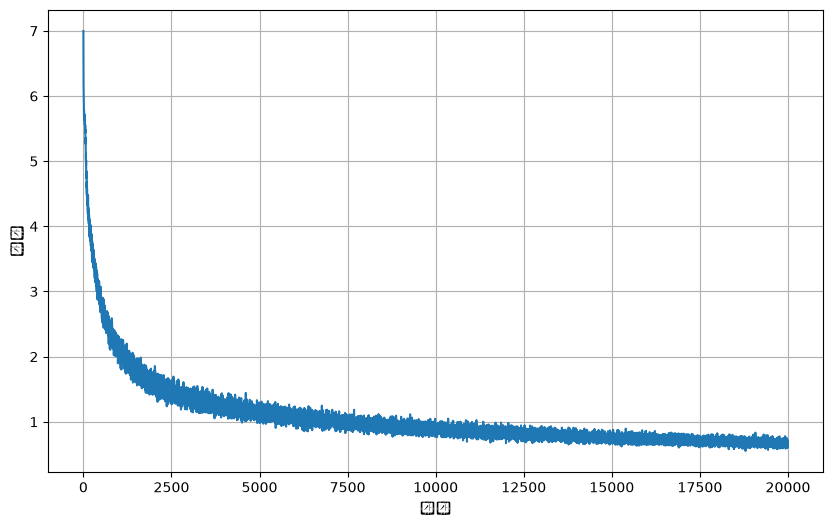

In [10]:
for i in pbar:
    batch_x, batch_y = next(data_iter)
    batch_x, batch_y = batch_x.to(device), batch_y.to(device)

    logits = model(batch_x)

    loss = F.cross_entropy(logits.view(-1, logits.size(-1)), batch_y.view(-1))

    optimizer.zero_grad()
    loss.backward()

    optimizer.step()

    losses.append(loss.item())
    pbar.set_postfix({'loss' : f'{loss.item():.4f}'})

plt.figure(figsize = (10,6))
plt.plot(losses)
plt.xlabel('반복')
plt.ylabel('손실')
plt.grid(True)
plt.savefig('loss.pretrain.png')

model.save(model_save_path)

In [11]:
import sys
sys.path.append('.')

import torch
import torch.nn.functional as F
from codebot.model import GPT
from codebot.tokenizer import BPETokenizer
from codebot.utils import get_device
from codebot.utils import generate

device = get_device()

print(device)

model_save_path = 'codebot/model_pretrain.pt'
tokenizer_path = 'codebot/merge_rules.pkl'

prompt = 'def'
max_new_tokens = 200
temperature = 1.0

tokenizer = BPETokenizer.load_from(tokenizer_path)
model = GPT.load_from(model_save_path, device = device)

cuda


In [12]:
for i in range(5):
    print(i)
    generated_text = generate(
        model = model,
        tokenizer = tokenizer,
        prompt = prompt,
        max_new_tokens = max_new_tokens,
        temperature = temperature
    )
    print(generated_text)
    print()

0
def remove_vowels(string):
  vowels = ["a", "e", "i", "o", "u"]
  return string.count(char)

print(remove_vowels(string))


1
def detectMax(x):

    def __init__(self, x, y):
        super().__init__()
        self.x = x
        self.y = y

    def __add__(self, other):
        return Vector(self.x + other.x, self.y + other.y)

    def __sub__(self, other):
        return Vector(self.x - other.x, self.y - other.y)

    def __sub__(self, other):
        return Vector(self.x - other.x, self.y - other.y)


2
def reverse_list(list):
 half = 0
 temp = list[0]
 while temp >= temp:
 h = temp % 10
 mid = temp // 10
 temp = temp

 # reverse list and print(temp)

# print the reversed list and print the reversed input
reverse_list(half)


3
defggl(code):
    data = []
    for link in files:
        node = dlib.load_doc(line.split('"))
        for link in link.split(": ")[1]:
            if link.startswith('http'):
                link = link.get('href')
                links.append(link)
    re

In [13]:
import sys
sys.path.append(".")

import json
from codebot.tokenizer import BPETokenizer

tokenizer = BPETokenizer.load_from("codebot/merge_rules.pkl")

with open("codebot/tiny_codes_sft.json") as f:
    data = json.load(f)

item = data[0]
print(item)

#알파카포멧
text = f"### Instruction:\n{item['instruction']}\n\n### Response:\n{item['response']}<|endoftext|>"
print(text)

ids = tokenizer.encode(text)
print(ids)

{'instruction': 'Hello', 'response': 'Hello. What can I help you with?'}
### Instruction:
Hello

### Response:
Hello. What can I help you with?<|endoftext|>
[35, 35, 35, 962, 519, 117, 389, 58, 10, 846, 10, 10, 35, 35, 35, 752, 568, 58, 10, 846, 46, 840, 104, 277, 280, 356, 473, 708, 108, 112, 930, 657, 63, 999]


In [3]:
import sys
sys.path.append('.')

from itertools import cycle
import json
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from tqdm import tqdm
from codebot.model import GPT
from codebot.tokenizer import BPETokenizer
from codebot.utils import get_device

In [10]:
device = get_device()
print(device)

data_path = "codebot/tiny_codes_sft.json"
tokenizer_path = "codebot/merge_rules.pkl"
pretrain_model_path = "codebot/model_pretrain.pt"
sft_model_save_path = "codebot/model_sft.pt"

context_len = 256
batch_size = 32
learning_rate = 3e-4
max_iters = 500

cuda


In [11]:
class SFTDataset(Dataset):
    def __init__(self, data_path, tokenizer, context_len):
        self.tokenizer = tokenizer
        self.context_len = context_len
        self.samples = []

        with open(data_path) as f:
            data = json.load(f)

        for item in data:
            ids, labels = self._create_sample(item['instruction'], item['response'])
            self.samples.append((ids, labels))

    def _create_sample(self, instruction, response):
        prompt = f"### Instruction\n{instruction}\n\n### Response:\n"
        response = f"{response}<|endoftext|>"

        prompt_ids = self.tokenizer.encode(prompt)
        response_ids = self.tokenizer.encode(response)

        ids = prompt_ids + response_ids
        labels = [-100] * len(prompt_ids) + response_ids

        ids = ids[:-1]
        labels = labels[1:]

        pad_len = self.context_len - len(ids)
        if pad_len > 0:
            ids = ids + [0] * pad_len
            labels = labels + [-100] * pad_len

        elif pad_len < 0:
            ids = ids[:self.context_len]
            labels = labels[:self.context_len]

        return ids , labels

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ids, labels = self.samples[idx]
        return torch.tensor(ids, dtype= torch.long), torch.tensor(labels, dtype = torch.long)

In [12]:
tokenizer = BPETokenizer.load_from(tokenizer_path)
dataset = SFTDataset(data_path, tokenizer, context_len)
dataloader = DataLoader(dataset, batch_size= batch_size, shuffle= True)

model = GPT.load_from(pretrain_model_path, device = device)
optimizer = torch.optim.AdamW(model.parameters(), lr = learning_rate)

losses = []
data_iter = cycle(dataloader)

100%|██████████| 500/500 [00:57<00:00,  8.65it/s, loss=(loss.item():.4f)]


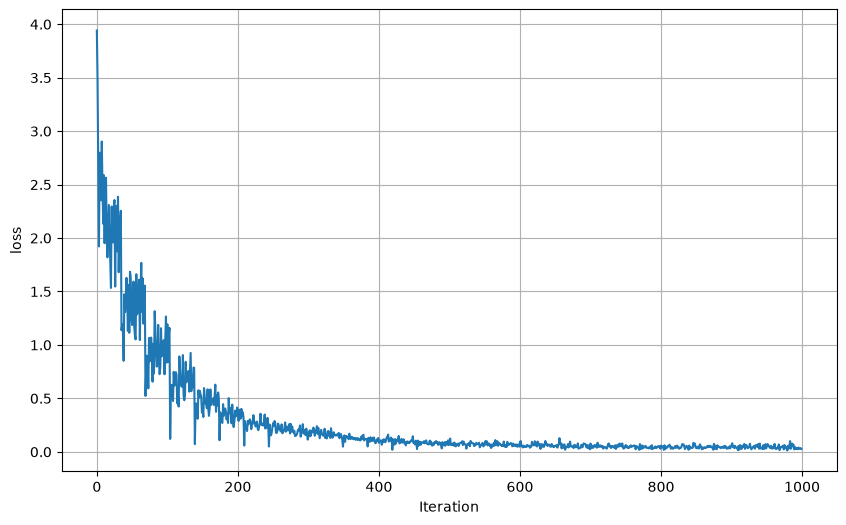

In [14]:
pbar = tqdm(range(max_iters))

for i in pbar:
    batch_x, batch_y = next(data_iter)
    batch_x, batch_y = batch_x.to(device), batch_y.to(device)

    logits = model(batch_x)
    loss = F.cross_entropy(
        logits.view(-1, logits.size(-1)),
        batch_y.view(-1),
        ignore_index= -100
    )
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    pbar.set_postfix({'loss': f'(loss.item():.4f)'})

plt.figure(figsize = (10,6))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('loss')
plt.grid(True)
plt.savefig('loss_sft.png')

model.save(sft_model_save_path)

In [18]:
import sys
sys.path.append('.')

from codebot.model import GPT
from codebot.tokenizer import BPETokenizer
from codebot.utils import generate, get_device

device = get_device()
print(device)

model_path = 'codebot/model_sft.pt'
tokenizer_path = 'codebot/merge_rules.pkl'
max_new_tokens = 200
temperature = 1.0

def format_prompt(user_message):
    return f'### Instruction:\n{user_message}\n\n### Response:\n'

tokenizer = BPETokenizer.load_from(tokenizer_path)
model = GPT.load_from(model_path, device= device)

while True:
    user_input = input('\nYou:').strip()

    if not user_input:
        continue

    prompt = format_prompt(user_input)
    response = generate(
    model=model,
    tokenizer=tokenizer,
    prompt=prompt,
    max_new_tokens=max_new_tokens,
    temperature=temperature
)

    if '### Response:' in response:
        response = response.split('### Response:')[-1].strip()

    if '\n' in response:
        print(f'Bot:\n{response}')

    else: 
        print(f'Bot: {response}')

cuda
Bot: Hello. What can I help you with?


KeyboardInterrupt: Interrupted by user